In [30]:
import os

BASE_DIR = os.getcwd()

TRAIN_IMG = os.path.join(BASE_DIR, "data_processed/train/images")
TRAIN_MASK = os.path.join(BASE_DIR, "data_processed/train/masks")

VAL_IMG = os.path.join(BASE_DIR, "data_processed/val/images")
VAL_MASK = os.path.join(BASE_DIR, "data_processed/val/masks")

In [45]:
from dataset import get_loaders
from torch.utils.data import DataLoader

train_loader, test_loader = get_loaders(
    TRAIN_IMG, TRAIN_MASK,
    VAL_IMG, VAL_MASK
)


imgs, masks = next(iter(train_loader))

print(imgs.shape)   # [B,4,256,256]
print(masks.shape)  # [B,256,256]
print(masks.unique())

torch.Size([4, 4, 256, 256])
torch.Size([4, 256, 256])
tensor([0, 1, 2, 3])


In [32]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from tqdm import tqdm


In [33]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
EPOCHS = 30
LR = 1e-4


In [34]:
class_weights = torch.tensor([0.05, 1, 1, 1]).to(DEVICE)

ce_loss = nn.CrossEntropyLoss(weight=class_weights, reduction='mean')

def dice_loss(pred, target, smooth=1e-5):
    pred = torch.softmax(pred, dim=1)
    target_onehot = F.one_hot(target, num_classes=4).permute(0,3,1,2)

    intersection = (pred * target_onehot).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target_onehot.sum(dim=(2,3))

    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

def loss_fn(pred, target):
    return ce_loss(pred, target) + dice_loss(pred, target)

In [35]:
def dice_score(pred, target, num_classes=4, smooth=1e-5):
    pred = torch.argmax(pred, dim=1)

    dice = 0
    for cls in range(1, num_classes):  # ignore background (0)
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice += (2 * intersection + smooth) / (union + smooth)

    return dice / (num_classes - 1)

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.d1 = DoubleConv(4, 64)
        self.d2 = DoubleConv(64, 128)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            DoubleConv(128, 256),
            nn.Dropout2d(0.3)   # helps generalization
        )

        # Decoder
        self.u1 = DoubleConv(256 + 128, 128)
        self.u2 = DoubleConv(128 + 64, 64)

        # OUTPUT → 4 classes (FIXED)
        self.out = nn.Conv2d(64, 4, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.d1(x)
        x2 = F.max_pool2d(x1, 2)

        x3 = self.d2(x2)
        x4 = F.max_pool2d(x3, 2)

        # Bottleneck
        x5 = self.bottleneck(x4)

        # Decoder
        x6 = F.interpolate(x5, scale_factor=2, mode='bilinear', align_corners=False)
        x6 = torch.cat([x6, x3], dim=1)
        x6 = self.u1(x6)

        x7 = F.interpolate(x6, scale_factor=2, mode='bilinear', align_corners=False)
        x7 = torch.cat([x7, x1], dim=1)
        x7 = self.u2(x7)

        return self.out(x7)

In [37]:
model = UNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
print(len(train_loader))
print(len(test_loader))

1827
447


In [52]:
from tqdm import tqdm

EPOCHS = 10
best_dice = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    loop = tqdm(train_loader)

    for imgs, masks in loop:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() / imgs.size(0)

        # update progress bar
        loop.set_postfix(loss=loss.item())

    # ===== VALIDATION =====
    model.eval()
    val_dice = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(imgs)
            val_dice += dice_score(outputs, masks).item()

    val_dice /= len(val_loader)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.3f} | Dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved Best Model")


Epoch 1/10


100%|██████████| 1827/1827 [04:09<00:00,  7.32it/s, loss=0.525]


Epoch 1 | Loss: 264.113 | Dice: 0.5403
Saved Best Model

Epoch 2/10


100%|██████████| 1827/1827 [12:02<00:00,  2.53it/s, loss=0.382]  


Epoch 2 | Loss: 264.478 | Dice: 0.5443
Saved Best Model

Epoch 3/10


...

Epoch 8 | Loss: 264.485 | Dice: 0.5510

Epoch 9/10


100%|██████████| 1827/1827 [05:00<00:00,  6.08it/s, loss=0.712]


Epoch 9 | Loss: 264.474 | Dice: 0.5466

Epoch 10/10


100%|██████████| 1827/1827 [05:05<00:00,  5.98it/s, loss=0.606]


Epoch 10 | Loss: 263.704 | Dice: 0.5420


In [41]:
model = UNet().to(DEVICE)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

UNet(
  (d1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (d2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (bottleneck): Sequential(
    (0): DoubleConv(
      (net): Sequential(
        (0): Conv2

In [48]:
def dice_score(pred, target, num_classes=4, smooth=1e-5):
    pred = torch.argmax(pred, dim=1)

    dice = 0
    for cls in range(1, num_classes):  # ignore background
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice += (2 * intersection + smooth) / (union + smooth)

    return dice / (num_classes - 1)

def precision_recall_f1(pred, target, num_classes=4, eps=1e-8):
    pred = torch.argmax(pred, dim=1)

    precision_list = []
    recall_list = []
    f1_list = []

    for cls in range(1, num_classes):  # ignore background (0)
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        TP = (pred_cls * target_cls).sum()
        FP = (pred_cls * (1 - target_cls)).sum()
        FN = ((1 - pred_cls) * target_cls).sum()

        precision = TP / (TP + FP + eps)
        recall = TP / (TP + FN + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    return (
        torch.mean(torch.stack(precision_list)),
        torch.mean(torch.stack(recall_list)),
        torch.mean(torch.stack(f1_list))
    )

In [ ]:
def evaluate(model, loader):
    model.eval()

    total_prec, total_rec, total_f1 = 0, 0, 0
    total_dice = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(imgs)

            prec, rec, f1 = precision_recall_f1(outputs, masks)
            dice = dice_score(outputs, masks)

            total_prec += prec.item()
            total_rec += rec.item()
            total_f1 += f1.item()
            total_dice += dice.item()

    n = len(loader)

    print("\n TEST RESULTS")
    print(f"Precision: {total_prec/n:.4f}")
    print(f"Recall:    {total_rec/n:.4f}")
    print(f"F1 Score:  {total_f1/n:.4f}")
    print(f"Dice:      {total_dice/n:.4f}")

In [55]:
evaluate(model, test_loader)


📊 TEST RESULTS
Precision: 0.4260
Recall:    0.4659
F1 Score:  0.3951
Dice:      0.5420


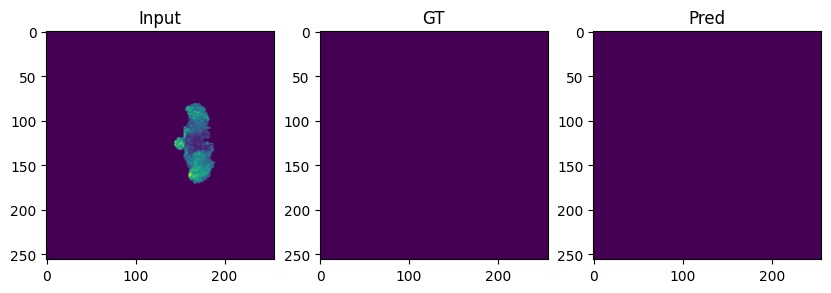

In [56]:
import matplotlib.pyplot as plt

imgs, masks = next(iter(test_loader))
imgs = imgs.to(DEVICE)

with torch.no_grad():
    preds = model(imgs)

preds = torch.argmax(preds, dim=1).cpu()

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(imgs[0][0].cpu())

plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(masks[0])

plt.subplot(1,3,3)
plt.title("Pred")
plt.imshow(preds[0])

plt.show()